<a href="https://colab.research.google.com/github/ragadtq2003-maker/final-project-ML-stroke-prediction-using-Machine-Learning/blob/main/Stroke_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Final Project ML
### Raghad Talal Qwaider
### 2301214228

## " Stroke Prediction By using ML "
### Stroke is a sudden and life-threatening medical condition that can lead to severe complications or death if not detected and treated promptly. Early identification of individuals at high risk of stroke can help reduce its complications and mortality. Machine learning techniques provide an effective approach for predicting stroke risk based on health and demographic factors such as age, hypertension, heart disease, average blood glucose level, smoking status, and body mass index (BMI).

###In this project, we develop a supervised machine learning classification model to predict whether an individual is at risk of experiencing a stroke using the Healthcare Stroke Dataset.

### Before preparing the dataset, we will import the libraries.

In [ ]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Data Encoding
from sklearn.preprocessing import LabelEncoder


# Data preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# Model Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
from sklearn.model_selection import cross_val_score


The dataset is first loaded into a Pandas .

 Then, several functions are used to understanding the data.

1-head() function displays the first five rows of the dataset .

2-info() provides information about the data types and missing values .

3-shape returns the number of rows and columns .

4-and describe() generates descriptive statistics for the numerical features.

In [ ]:
df = pd.read_csv('healthcare-dataset-stroke-data.csv')
df

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0


In [ ]:
df.shape

(5110, 12)

In [ ]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [ ]:
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


## **Preprocessing** **Dataset**
###1-Cleaning Data
* **missing** **values** : Only the BMI feature contained missing values. These missing values were processing it by the median because it is less sensitive to outliers than the mean.

In [ ]:
df.isnull().sum()

,0
id,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,201


In [ ]:
df['bmi'] = df['bmi'].fillna(df['bmi'].median())

In [ ]:
df.isnull().sum()

,0
id,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,0


* **duplicated** **values** : The dataset was checked for duplicate records . No duplicate records were found .

In [ ]:
df.duplicated().sum()

np.int64(0)

* **Outlier** **Values** : Boxplots were used to detect outliers in the numerical features.

 The Age feature showed no outliers, while Avg_Glucose_Level and BMI contained several outliers.

 Then , we use IQR method to process it .

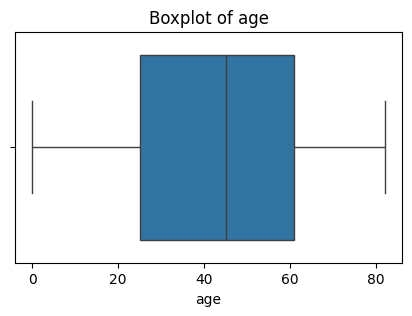

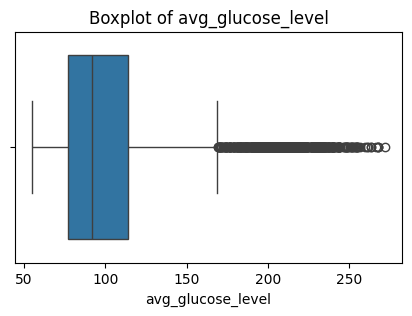

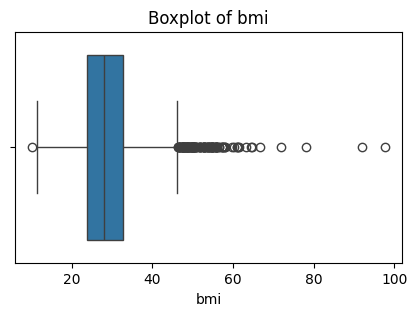

In [ ]:
numerical_cols = ['age', 'avg_glucose_level', 'bmi']

for col in numerical_cols:
    plt.figure(figsize=(5,3))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

In [ ]:
outlier_cols = ['avg_glucose_level', 'bmi']

for col in outlier_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

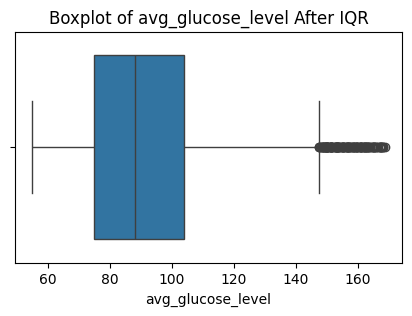

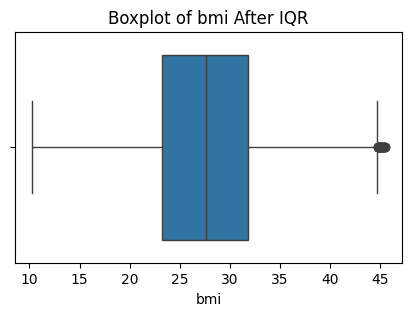

In [ ]:
outlier_cols = ['avg_glucose_level', 'bmi']

for col in outlier_cols:

    plt.figure(figsize=(5,3))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col} After IQR')
    plt.show()

### 2-Encoding
Encoding is a preprocessing technique used to convert categorical features into numerical values, allowing machine learning models to process and learn from the data effectively.

In [ ]:
categorical_cols = df.select_dtypes(include='object').columns
print(categorical_cols)

Index(['gender', 'ever_married', 'work_type', 'Residence_type',
       'smoking_status'],
      dtype='object')


In [ ]:
df['ever_married'].unique()

array(['Yes', 'No'], dtype=object)

In [ ]:
df['Residence_type'].unique()

array(['Rural', 'Urban'], dtype=object)

In [ ]:
# Label Encoding Bec. them have only tow values

label_encoder = LabelEncoder()
df['ever_married'] = label_encoder.fit_transform(df['ever_married'])
df['Residence_type'] = label_encoder.fit_transform(df['Residence_type'])

In [ ]:
df['gender'].unique()

array(['Male', 'Female', 'Other'], dtype=object)

In [ ]:
df['work_type'].unique()

array(['Private', 'Govt_job', 'Self-employed', 'children', 'Never_worked'],
      dtype=object)

In [ ]:
df['smoking_status'].unique()

array(['never smoked', 'Unknown', 'smokes', 'formerly smoked'],
      dtype=object)

In [ ]:
# one hot encoding bec. them have over tow values
df = pd.get_dummies(
    df,
    columns=['gender', 'work_type', 'smoking_status'],
    drop_first=False,
    dtype=int
)

In [ ]:
df

,id,age,hypertension,heart_disease,ever_married,Residence_type,avg_glucose_level,bmi,stroke,gender_Female,...,gender_Other,work_type_Govt_job,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,smoking_status_Unknown,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
2,31112,80.0,0,1,1,0,105.92,32.5,1,0,...,0,0,0,1,0,0,0,0,1,0
6,53882,74.0,1,1,1,0,70.09,27.4,1,0,...,0,0,0,1,0,0,0,0,1,0
7,10434,69.0,0,0,0,1,94.39,22.8,1,1,...,0,0,0,1,0,0,0,0,1,0
8,27419,59.0,0,0,1,0,76.15,28.1,1,1,...,0,0,0,1,0,0,1,0,0,0
9,60491,78.0,0,0,1,1,58.57,24.2,1,1,...,0,0,0,1,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,80.0,1,0,1,1,83.75,28.1,0,1,...,0,0,0,1,0,0,0,0,1,0
5106,44873,81.0,0,0,1,1,125.20,40.0,0,1,...,0,0,0,0,1,0,0,0,1,0
5107,19723,35.0,0,0,1,0,82.99,30.6,0,1,...,0,0,0,0,1,0,0,0,1,0
5108,37544,51.0,0,0,1,0,166.29,25.6,0,0,...,0,0,0,1,0,0,0,1,0,0


In [ ]:
df.shape

(4383, 21)

### 3-Feature Engineering
* Feature engineering is the process of creating new features or modifying existing ones to improve the performance of machine learning models.
* In my project, no additional features were created because the dataset already contains relevant and informative features related to stroke prediction


## **EDA** :
#### Exploratory data analysis (EDA) to visually understand the dataset before building the model.


* The target variable is highly imbalanced. Most samples belong to the non-stroke class (0), while only a small proportion belongs to the stroke class (1). This imbalance should be considered when evaluating the machine learning models.

* This is an important conclusion because data imbalance means that when evaluating models, it is not enough to rely only on Accuracy, but also use metrics such as Precision, Recall, and F1-score

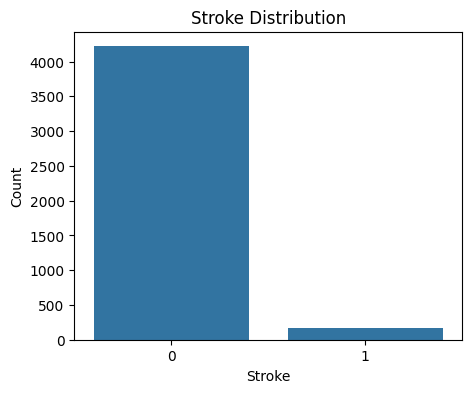

In [ ]:
plt.figure(figsize=(5,4))

sns.countplot(x='stroke', data=df)

plt.title("Stroke Distribution")
plt.xlabel("Stroke")
plt.ylabel("Count")

plt.show()

* The Histogram shows how people's ages spread in the datast. It turns out that the ages extend from approximately newborns to about 82 years, with the largest number of samples concentrated around the age of 40.

* A blood glucose level distribution chart (Histogram) shows how glucose values spread among members of the datast. Note that most values are concentrated between 70 and 100 (Right Skewed)

* A body mass index (BMI) distribution chart shows how BMI values are spread among datast individuals. Observe that most values are concentrated between 20 and 35, with the highest density around 27–30 (Right Skewed)

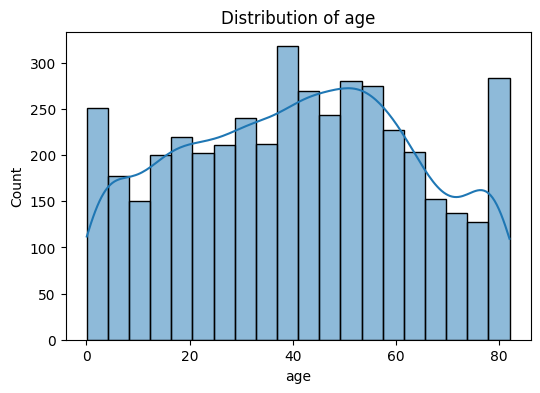

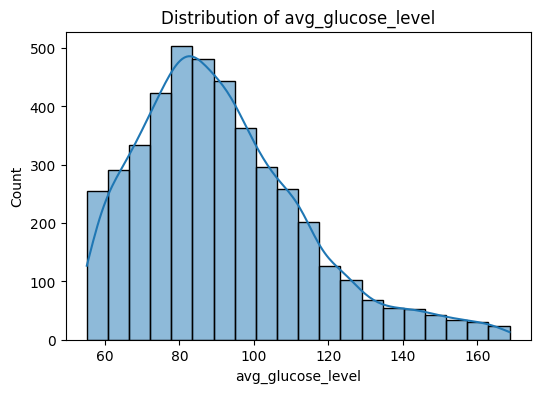

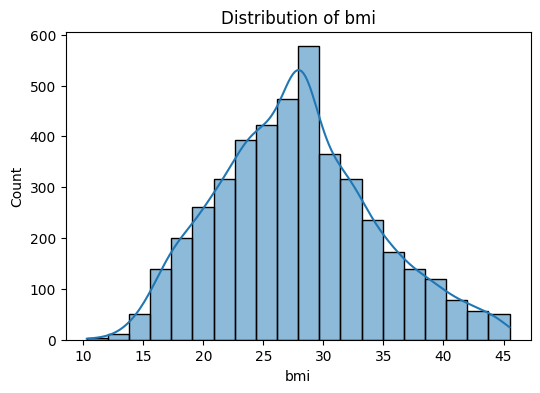

In [ ]:
numerical_cols = ['age', 'avg_glucose_level', 'bmi']

for col in numerical_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], bins=20, kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()

* Correlation Matrix
The correlation matrix illustrates the strength and direction of the relationships between the numerical features and the target variable (Stroke). It helps identify the most relevant features for prediction and detect highly correlated variables.

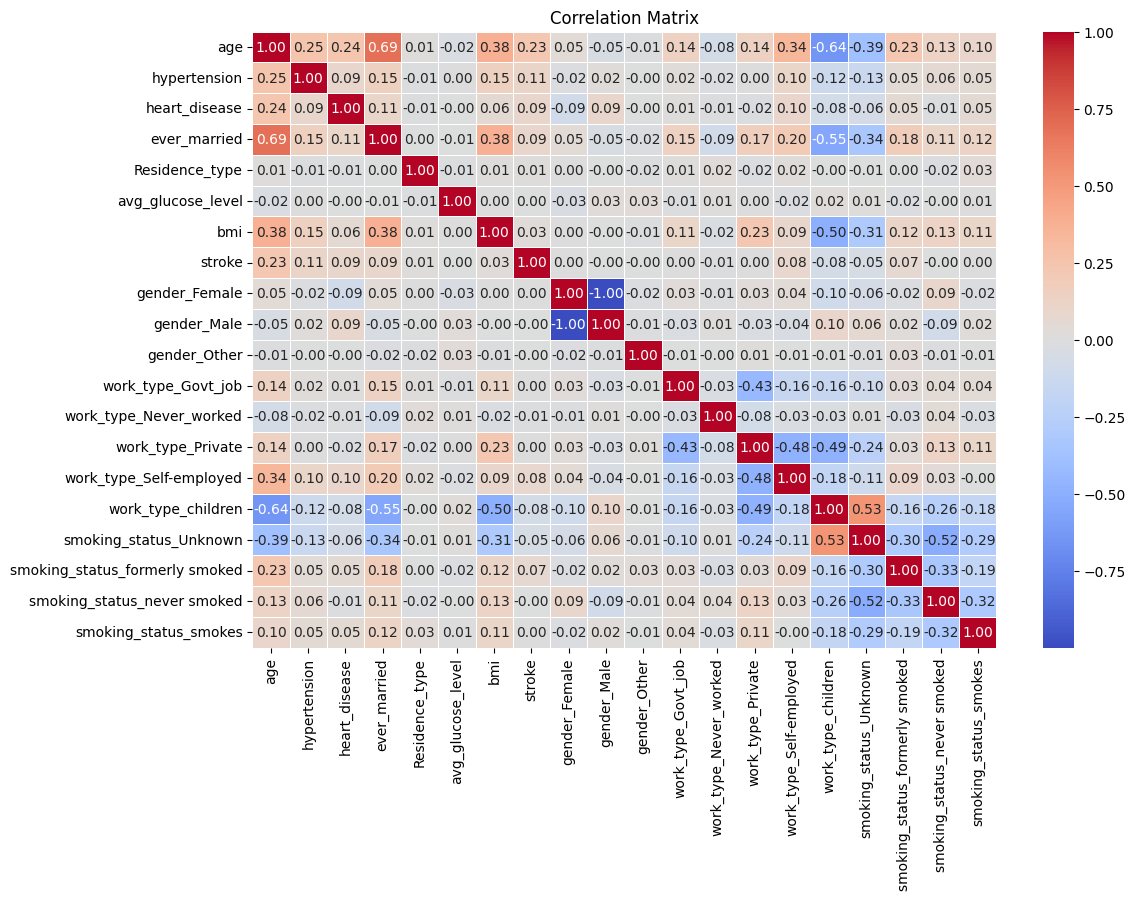

In [ ]:
plt.figure(figsize=(12,8))
corr = df.drop(columns=['id']).corr(numeric_only=True)
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5
)
plt.title("Correlation Matrix")
plt.show()

* **Age**: has the highest positive association with stroke, indicating that increased age is associated with an increased risk of injury.

* **Residence** **Type**: Does not show a clear relationship with stroke.

* **Gender**: Does not show a clear effect on stroke.

### **Model** **Implementation**

* Before building the machine learning models, the dataset was divided into input features (X) and the target variable (y), where the stroke column was selected as the prediction target and all remaining columns were used as input features.

*  The dataset was then split into training and testing sets using an 80:20 ratio , with stratified sampling to preserve the original class distribution in both sets.

 * Finally, StandardScaler was applied to the numerical features (age, avg_glucose_level, and bmi) to standardize their values by giving them a mean of 0 and a standard deviation of 1.

 * This step improves the performance of Logistic Regression, while it was not applied to Decision Tree because tree-based models are not affected by feature scaling.

In [ ]:
# Define Features and Target
X = df.drop('stroke', axis=1)
y = df['stroke']

In [ ]:
# Split the Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
# StandardScaler on Logistic Regression data only
scaler = StandardScaler()
numerical_cols = ['age', 'avg_glucose_level', 'bmi']
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test_scaled[numerical_cols] = scaler.transform(X_test[numerical_cols])

* The Logistic Regression model was trained using the scaled training data. After training, the model was used to predict the stroke outcome on the testing data.

In [ ]:
log_model = LogisticRegression(
    random_state=42,
    max_iter=5000,
    class_weight='balanced'
)
# Train the model
log_model.fit(X_train_scaled, y_train)

# Predict on test data
y_pred_log = log_model.predict(X_test_scaled)

* The Decision Tree model was built using the training data to learn the relationship between the input features and the target variable. The original data were used because feature scaling is not required for tree-based models. The trained model was then applied to the testing data to predict stroke outcomes.

In [ ]:
# Create Decision Tree model
dt_model = DecisionTreeClassifier(
    random_state=42
)

# Train the model
dt_model.fit(X_train, y_train)

# Predict on test data
y_pred_dt = dt_model.predict(X_test)

In [ ]:
print("Logistic Regression")
print("Accuracy :", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log, zero_division=0))
print("Recall   :", recall_score(y_test, y_pred_log, zero_division=0))
print("F1-score :", f1_score(y_test, y_pred_log, zero_division=0))

Logistic Regression
Accuracy : 0.7628278221208666
Precision: 0.1145374449339207
Recall   : 0.7878787878787878
F1-score : 0.2


In [ ]:
print("Decision Tree")
print("Accuracy :", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt, zero_division=0))
print("Recall   :", recall_score(y_test, y_pred_dt, zero_division=0))
print("F1-score :", f1_score(y_test, y_pred_dt, zero_division=0))

Decision Tree
Accuracy : 0.9258836944127709
Precision: 0.13636363636363635
Recall   : 0.18181818181818182
F1-score : 0.15584415584415584


* Although the Decision Tree achieved the highest Accuracy (92.6%), the Logistic Regression model achieved a much higher Recall (78.8%) and a better F1-score (20.0%). Since the main objective of this study is medical diagnosis, where detecting patients is more important than maximizing overall accuracy, Logistic Regression is considered the more suitable model for this dataset.

### 1. Confusion Matrix
* Logistic Regression

The Logistic Regression model correctly identified most stroke cases (26 TP) and missed only 7 patients (FN). However, it produced 201 false positives, resulting in high Recall but lower Precision.

* Decision Tree

The Decision Tree model correctly classified most healthy individuals (806 TN) but detected only 6 stroke cases (TP) and missed 27 patients (FN). This resulted in high Accuracy but low Recall.

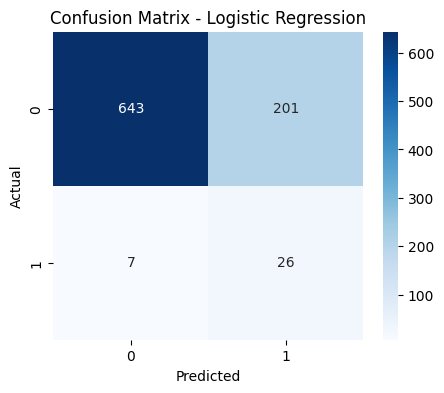

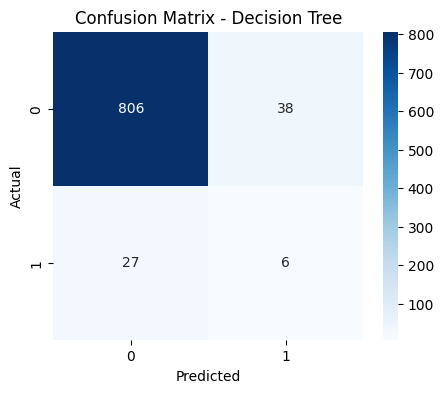

In [ ]:
# Logistic Regression
cm_log = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(5,4))
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Decision Tree
cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(5,4))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### 2. Classification Report
* The classification report summarizes the performance of each model by reporting Precision, Recall, F1-score, and Support for each class, providing a detailed evaluation of the classification results.

In [ ]:
print("Logistic Regression Report")
print(classification_report(y_test, y_pred_log, zero_division=0))

print("Decision Tree Report")
print(classification_report(y_test, y_pred_dt, zero_division=0))

Logistic Regression Report
              precision    recall  f1-score   support

           0       0.99      0.76      0.86       844
           1       0.11      0.79      0.20        33

    accuracy                           0.76       877
   macro avg       0.55      0.77      0.53       877
weighted avg       0.96      0.76      0.84       877

Decision Tree Report
              precision    recall  f1-score   support

           0       0.97      0.95      0.96       844
           1       0.14      0.18      0.16        33

    accuracy                           0.93       877
   macro avg       0.55      0.57      0.56       877
weighted avg       0.94      0.93      0.93       877



### 3. Cross Validation
* Cross Validation is used to verify that the model has learned the underlying patterns in the data rather than simply memorizing a single training split. The dataset is divided into several folds, and the model is trained and tested multiple times. Consistent performance across the folds indicates that the model generalizes well to unseen data.

In [36]:
log_cv = cross_val_score(log_model, X_train_scaled, y_train, cv=5, scoring='f1')
dt_cv = cross_val_score(dt_model, X_train, y_train, cv=5, scoring='f1')
print("Logistic Regression CV F1:", log_cv.mean())
print("Decision Tree CV F1:", dt_cv.mean())

Logistic Regression CV F1: 0.17685117620597715
Decision Tree CV F1: 0.13032631602546857


### 4. Comparison Table
* A comparison table was generated to summarize and compare the evaluation metrics of the two models, making it easier to determine the best-performing model.

In [37]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_dt)
    ],
    'Precision': [
        precision_score(y_test, y_pred_log, zero_division=0),
        precision_score(y_test, y_pred_dt, zero_division=0)
    ],
    'Recall': [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_dt)
    ],
    'F1-score': [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_dt)
    ]
})

results.round(3)

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.763,0.115,0.788,0.200
1,Decision Tree,0.926,0.136,0.182,0.156


## conclusion
* In this project, the stroke prediction dataset was preprocessed through data cleaning, encoding categorical features, and scaling numerical features when required. Exploratory Data Analysis (EDA) was performed to better understand the data and the relationships between variables. The dataset was then divided into training and testing sets, and two machine learning models, Logistic Regression and Decision Tree, were developed and trained. Their performance was evaluated using Accuracy, Precision, Recall, F1-score, Confusion Matrix, and Classification Report. Finally, the results of both models were compared to determine the most suitable model for stroke prediction.


* **Logistic** **Regression** was selected as the **best** **model** because it achieved the **highest** **Recall** and **F1**-**score**. Although Decision Tree had higher Accuracy, Logistic Regression was more effective in detecting stroke cases, making it more suitable for medical diagnosis.
